<a href="https://colab.research.google.com/github/Anzonfire/Machine-Learning/blob/main/expno6/scenario%202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Columns in dataset: Index(['Tenure', 'MonthlyCharges', 'ContractType', 'InternetService', 'Churn'], dtype='object')

=== AdaBoost ===
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        24

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24


=== Gradient Boosting ===
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        24

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


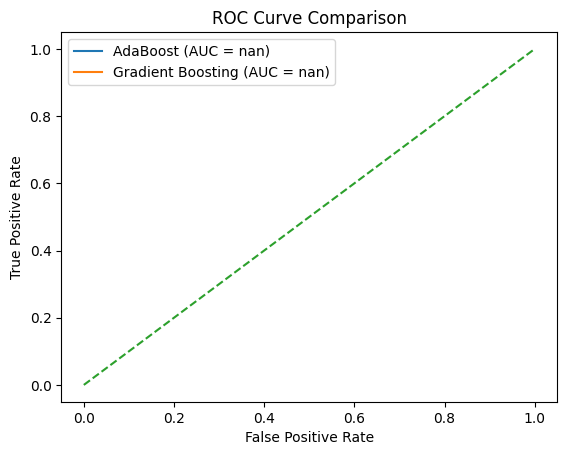

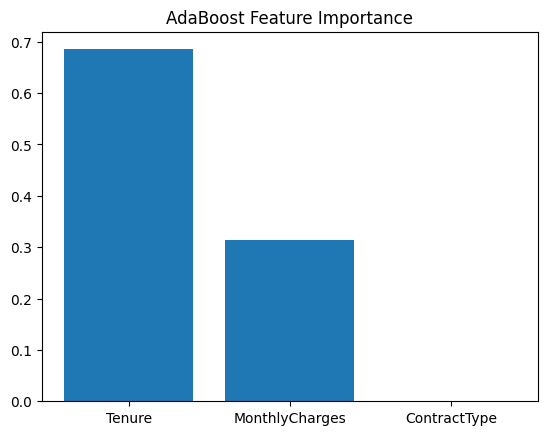

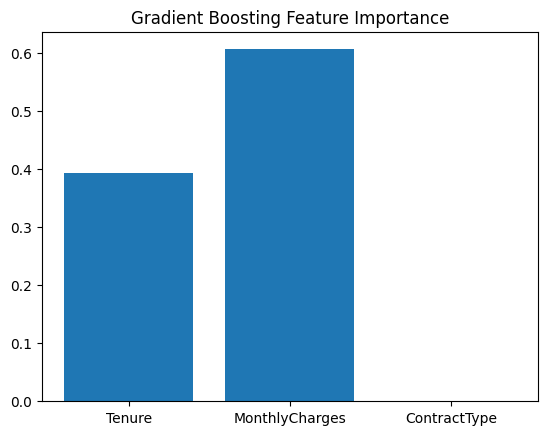

In [5]:
# ==============================
# IMPORT LIBRARIES
# ==============================
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc

# ==============================
# LOAD DATASET
# ==============================
df = pd.read_csv("Churn.csv")

# Check columns
print("Columns in dataset:", df.columns)

# ==============================
# SELECT REQUIRED FEATURES
# ==============================
df = df[['Tenure', 'MonthlyCharges', 'ContractType', 'Churn']]

# ==============================
# HANDLE MISSING VALUES
# ==============================
df.dropna(inplace=True)

# ==============================
# ENCODE CATEGORICAL DATA
# ==============================
le = LabelEncoder()
df['ContractType'] = le.fit_transform(df['ContractType'])
df['Churn'] = le.fit_transform(df['Churn'])  # Yes=1, No=0

# ==============================
# SPLIT DATA
# ==============================
X = df[['Tenure', 'MonthlyCharges', 'ContractType']]
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# ADABOOST MODEL
# ==============================
ada = AdaBoostClassifier(n_estimators=50, random_state=42)
ada.fit(X_train, y_train)

y_pred_ada = ada.predict(X_test)
y_prob_ada = ada.predict_proba(X_test)[:, 1]

# ==============================
# GRADIENT BOOSTING MODEL
# ==============================
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:, 1]

# ==============================
# PERFORMANCE COMPARISON
# ==============================
print("\n=== AdaBoost ===")
print("Accuracy:", accuracy_score(y_test, y_pred_ada))
print(classification_report(y_test, y_pred_ada))

print("\n=== Gradient Boosting ===")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

# ==============================
# ROC CURVE
# ==============================
fpr_ada, tpr_ada, _ = roc_curve(y_test, y_prob_ada)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

auc_ada = auc(fpr_ada, tpr_ada)
auc_gb = auc(fpr_gb, tpr_gb)

plt.figure()
plt.plot(fpr_ada, tpr_ada, label="AdaBoost (AUC = %.2f)" % auc_ada)
plt.plot(fpr_gb, tpr_gb, label="Gradient Boosting (AUC = %.2f)" % auc_gb)
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# ==============================
# FEATURE IMPORTANCE
# ==============================
features = X.columns

# AdaBoost
plt.figure()
plt.bar(features, ada.feature_importances_)
plt.title("AdaBoost Feature Importance")
plt.show()

# Gradient Boosting
plt.figure()
plt.bar(features, gb.feature_importances_)
plt.title("Gradient Boosting Feature Importance")
plt.show()